In [2]:
!pip install ultralytics --upgrade --quiet

import os
import zipfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.0 MB/s eta 0:00:00


In [ ]:
# downloading VOC 2012 dataset
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# extract
!tar -xf VOCtrainval_11-May-2012.tar


--2025-05-24 14:01:52--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘VOCtrainval_11-May-2012.tar’

VOCtrainval_11-May- 100%[===================>]   1.86G  17.9MB/s    in 78s     

2025-05-24 14:03:10 (24.5 MB/s) - ‘VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]



In [ ]:
import xml.etree.ElementTree as ET
from tqdm import tqdm

# VOC class
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

CLASS_TO_ID = {cls: i for i, cls in enumerate(VOC_CLASSES)}

def convert_voc_to_yolo(voc_ann_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for xml_file in tqdm(os.listdir(voc_ann_path)):
        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(voc_ann_path, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_w = int(root.find("size/width").text)
        image_h = int(root.find("size/height").text)

        lines = []
        for obj in root.findall("object"):
            cls_name = obj.find("name").text
            if cls_name not in CLASS_TO_ID:
                continue

            cls_id = CLASS_TO_ID[cls_name]
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)


            # YOLO format: cx, cy, w, h (normalized)
            cx = ((xmin + xmax) / 2) / image_w
            cy = ((ymin + ymax) / 2) / image_h
            w = (xmax - xmin) / image_w
            h = (ymax - ymin) / image_h

            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # Save .txt
        txt_filename = xml_file.replace(".xml", ".txt")
        with open(os.path.join(output_dir, txt_filename), "w") as f:
            f.write("\n".join(lines))

voc_ann_path = "VOCdevkit/VOC2012/Annotations"
yolo_labels_output_dir = "VOCdevkit/VOC2012/labels"
convert_voc_to_yolo(voc_ann_path, yolo_labels_output_dir)


100%|██████████| 17125/17125 [00:04<00:00, 3601.31it/s]


In [ ]:
from shutil import copyfile

os.makedirs("datasets/VOC/images/train", exist_ok=True)
os.makedirs("datasets/VOC/images/val", exist_ok=True)
os.makedirs("datasets/VOC/labels/train", exist_ok=True)
os.makedirs("datasets/VOC/labels/val", exist_ok=True)

# train/val
with open("VOCdevkit/VOC2012/ImageSets/Main/train.txt") as f:
    train_ids = [line.strip() for line in f.readlines()]

with open("VOCdevkit/VOC2012/ImageSets/Main/val.txt") as f:
    val_ids = [line.strip() for line in f.readlines()]

for image_id in tqdm(train_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/train/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/train/{image_id}.txt")

for image_id in tqdm(val_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/val/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/val/{image_id}.txt")


100%|██████████| 5823/5823 [00:03<00:00, 1658.91it/s]


In [ ]:
yaml_content = """
path: datasets/VOC
train: images/train
val: images/val
nc: 20
names: [
  'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
  'bus', 'car', 'cat', 'chair', 'cow',
  'diningtable', 'dog', 'horse', 'motorbike', 'person',
  'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
"""

with open("VOC.yaml", "w") as f:
    f.write(yaml_content.strip())


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

train_path = "datasets/VOC/images/train"
val_path = "datasets/VOC/images/val"

train_files = {os.path.splitext(f)[0] for f in os.listdir(train_path) if f.endswith((".jpg", ".png"))}
val_files = {os.path.splitext(f)[0] for f in os.listdir(val_path) if f.endswith((".jpg", ".png"))}

duplicates = train_files.intersection(val_files)

if duplicates:
    print(f"❌ same images in train և val sets. count՝ {len(duplicates)}")
    print("Examples:", list(duplicates)[:5])
else:
    print("✅ there are not duplicates in train and val sets")

✅ there are not duplicates in train and val sets


In [ ]:
project_name = "yolov8m_colab_reg"
project_path = f"/content/drive/MyDrive/{project_name}"
model_path = f"{project_path}/weights/last.pt"


In [ ]:
results = model.train(
    data="VOC.yaml",
    epochs=50,
    imgsz=640,
    batch=32,
    name=project_path,
    workers=2,
    patience=25,
    save=True,
    val=True,
    device=0,
    flipud=0.1,
    fliplr=0.5,
    mixup=0.2,
    mosaic=0.6,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.5,
    copy_paste=0.1,
    lr0=0.0025,
    iou=0.5,
    label_smoothing=0.05,
    momentum=0.937,
    weight_decay=0.0005,
    ema=True
)


100%|██████████| 49.7M/49.7M [00:00<00:00, 227MB/s]


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.144 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.5, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.0015, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.9, mosaic=0.5, multi_scale=False, name=yolov8m_colab_reg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

100%|██████████| 755k/755k [00:00<00:00, 20.0MB/s]

Overriding model.yaml nc=80 with nc=20

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  2    517632  ultralytics.nn.modules.block.C2f             [576, 192, 2]                 
 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192, 192, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3787276  ultralytics.nn.modules.head.Detect           [20, 

...

      50/50      6.34G     0.5787     0.4243       1.01          7        640: 100%|██████████| 358/358 [03:06<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [01:07<00:00,  2.69it/s]

                   all       5823      15787      0.821      0.707      0.784      0.603



50 epochs completed in 3.619 hours.
Optimizer stripped from /content/drive/MyDrive/yolov8m_colab_reg/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/yolov8m_colab_reg/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/yolov8m_colab_reg/weights/best.pt...
Ultralytics 8.3.144 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [01:12<00:00,  2.51it/s]


                   all       5823      15787      0.822      0.706      0.784      0.603
             aeroplane        348        484      0.916       0.75      0.838      0.674
               bicycle        290        380       0.86      0.759      0.837      0.651
                  bird        374        629      0.861       0.66       0.77      0.585
                  boat        252        491      0.714      0.599      0.653      0.413
                bottle        369        733      0.777      0.576      0.673      0.472
                   bus        211        320      0.883      0.822      0.879      0.759
                   car        608       1173       0.86       0.72      0.822      0.611
                   cat        544        618      0.883      0.843       0.91      0.773
                 chair        642       1449      0.755       0.54      0.648      0.462
                   cow        154        347      0.764      0.756       0.79       0.62
           diningtabl

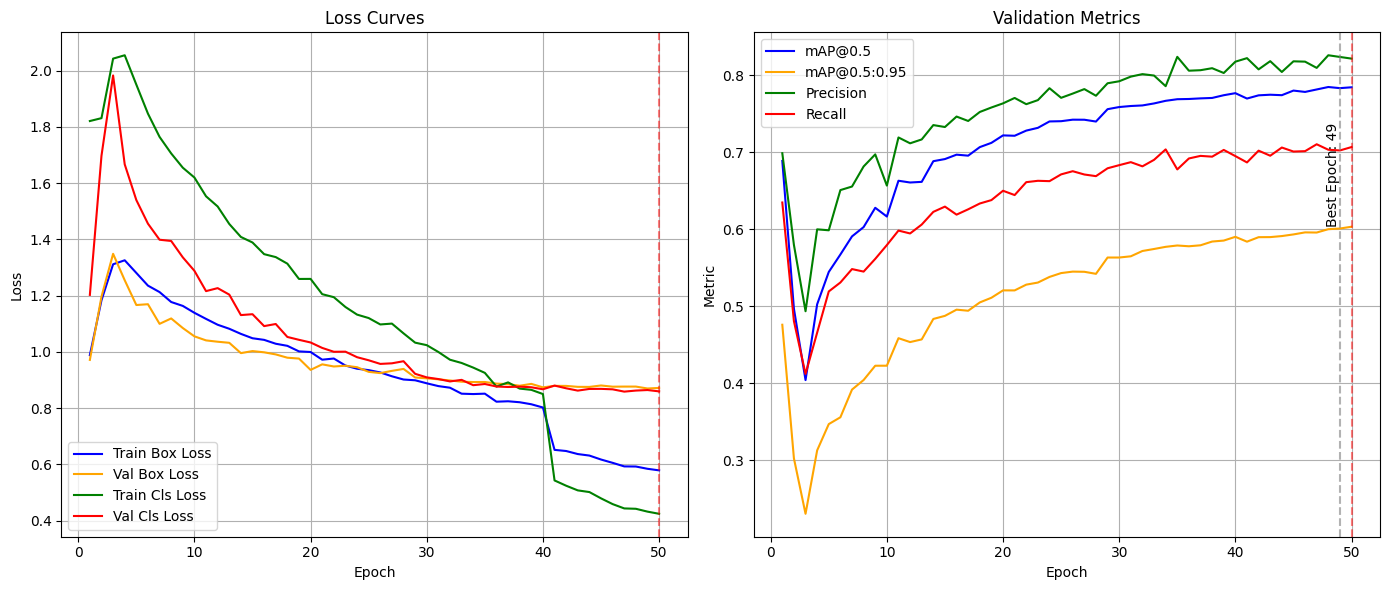

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'drive/MyDrive/yolov8m_colab_reg/results.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

epochs = df['epoch']
train_box = df['train/box_loss']
val_box = df['val/box_loss']
train_cls = df['train/cls_loss']
val_cls = df['val/cls_loss']
map50 = df['metrics/mAP50(B)']
map5095 = df['metrics/mAP50-95(B)']
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(epochs, train_box, label='Train Box Loss', color='blue')
ax1.plot(epochs, val_box, label='Val Box Loss', color='orange')
ax1.plot(epochs, train_cls, label='Train Cls Loss', color='green')
ax1.plot(epochs, val_cls, label='Val Cls Loss', color='red')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, map50, label='mAP@0.5', color='blue')
ax2.plot(epochs, map5095, label='mAP@0.5:0.95', color='orange')
ax2.plot(epochs, precision, label='Precision', color='green')
ax2.plot(epochs, recall, label='Recall', color='red')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.legend()
ax2.grid(True)

best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_map = df.loc[best_epoch, 'metrics/mAP50-95(B)']
ax2.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
ax2.text(best_epoch, best_map, f'Best Epoch: {best_epoch}', rotation=90, va='bottom', ha='right', fontsize=10)

last_epoch = df['epoch'].iloc[-1]
ax1.axvline(last_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stopping')
ax2.axvline(last_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stopping')

plt.tight_layout()
plt.show()


In [ ]:
# Best epoch data
best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_row = df.loc[best_epoch]

# Last epoch data
last_epoch = df['epoch'].iloc[-1]
last_row = df[df['epoch'] == last_epoch].iloc[0]

# Print
print(f"\n📌 Best Results (Epoch {best_epoch}):")
print(f"  mAP@0.5: {best_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {best_row['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision: {best_row['metrics/precision(B)']:.4f}")
print(f"  Recall: {best_row['metrics/recall(B)']:.4f}")

print(f"\n📌 Last Epoch Results (Epoch {last_epoch}):")
print(f"  mAP@0.5: {last_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {last_row['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision: {last_row['metrics/precision(B)']:.4f}")
print(f"  Recall: {last_row['metrics/recall(B)']:.4f}")



📌 Best Results (Epoch 49):
  mAP@0.5: 0.7841
  mAP@0.5:0.95: 0.6031
  Precision: 0.8214
  Recall: 0.7065

📌 Last Epoch Results (Epoch 50):
  mAP@0.5: 0.7841
  mAP@0.5:0.95: 0.6031
  Precision: 0.8214
  Recall: 0.7065



0: 416x640 1 bicycle, 1 car, 2 persons, 28.9ms
Speed: 2.4ms preprocess, 28.9ms inference, 2.8ms postprocess per image at shape (1, 3, 416, 640)
📌 Detection results for test1.jpg


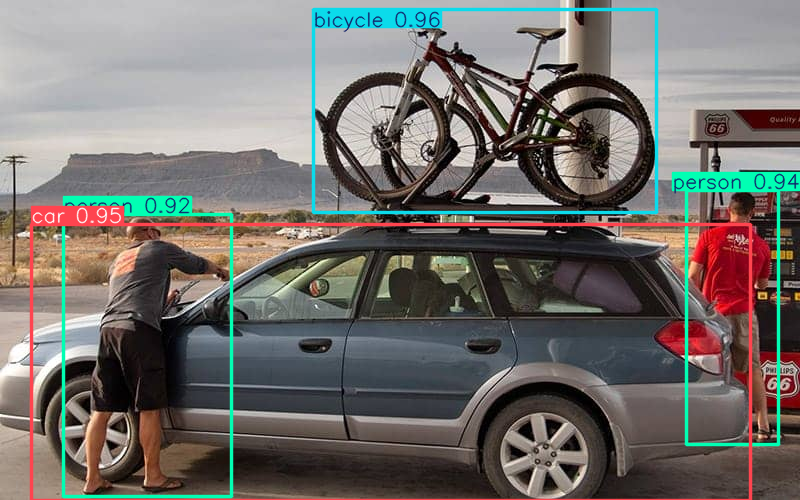


0: 480x640 1 bicycle, 1 car, 1 dog, 71.0ms
Speed: 3.2ms preprocess, 71.0ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)
📌 Detection results for test2.jpg


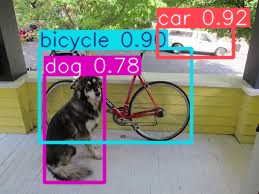

In [8]:
# Detection
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO("best.pt")

image_paths = ["test1.jpg", "test2.jpg"]

for path in image_paths:
    image = cv2.imread(path)
    results = model(image)
    annotated = results[0].plot()

    print(f"📌 Detection results for {path}")
    cv2_imshow(annotated)
